## Install Dependencies

In [8]:
!pip install -r ./requirements.txt


[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


## Imports

In [9]:
import os
import random
import shutil
import subprocess
from pathlib import Path
import matplotlib.pyplot as plt
import tensorflow as tf
from PIL import Image
import kagglehub

## GPU Detection

In [ ]:
gpus = tf.config.list_physical_devices('GPU')
if not gpus:
    print("CUDA is not available or no GPU was detected.")
build_info = tf.sysconfig.get_build_info()
cuda_version = build_info.get('cuda_version', 'unknown')
cudnn_version = build_info.get('cudnn_version', 'unknown')
gpu_names = []
for idx, gpu in enumerate(gpus):
    details = tf.config.experimental.get_device_details(gpu)
    name = gpu.name
    gpu_names.append(name)
    print(f"GPU {idx}: {name}")
    print(f"Details: {details}")
print(f"CUDA version detected by TensorFlow: {cuda_version}")
print(f"cuDNN version detected by TensorFlow: {cudnn_version}")

## System Resources

In [4]:
repo_root = Path.cwd()

cpu_count = os.cpu_count()

total_ram_gb = None
if hasattr(os, "sysconf"):
    names = getattr(os, "sysconf_names", {})
    if "SC_PAGE_SIZE" in names and "SC_PHYS_PAGES" in names:
        total_ram_bytes = os.sysconf("SC_PAGE_SIZE") * os.sysconf("SC_PHYS_PAGES")
        total_ram_gb = round(total_ram_bytes / 1024 ** 3, 2)

disk = shutil.disk_usage(repo_root)
disk_total_gb = round(disk.total / 1024 ** 3, 2)
disk_free_gb = round(disk.free / 1024 ** 3, 2)

print(f"CPUs detected: {cpu_count}")

if total_ram_gb is not None:
    print(f"Approx. total RAM: {total_ram_gb} GB")

print(
    f"Disk usage at {repo_root}: total {disk_total_gb} GB, free {disk_free_gb} GB"
)

nvidia_ok = False

try:
    result = subprocess.run(
        [
            "nvidia-smi",
            "--query-gpu=name,memory.total,memory.free",
            "--format=csv,noheader"
        ],
        capture_output=True,
        text=True,
        check=True,
    )

    print("nvidia-smi output:\n" + result.stdout)
    nvidia_ok = True

except FileNotFoundError:
    print("nvidia-smi was not found; ensure NVIDIA drivers are installed if you expect GPU support.")

except subprocess.CalledProcessError as exc:
    print("nvidia-smi returned an error:")
    print(exc.stderr)


CPUs detected: 20
Approx. total RAM: 31.05 GB
Disk usage at /home/emilio/Desktop/TESIS: total 551.87 GB, free 63.7 GB
nvidia-smi was not found; ensure NVIDIA drivers are installed if you expect GPU support.


## Create Data Directories

In [5]:
repo_root = Path.cwd()

data_root = Path(repo_root / "data").resolve()

raw_data_dir = data_root / "raw"
processed_data_dir = data_root / "processed"
models_dir = data_root / "models"

raw_data_dir.mkdir(parents=True, exist_ok=True)
processed_data_dir.mkdir(parents=True, exist_ok=True)
models_dir.mkdir(parents=True, exist_ok=True)

print("Prepared directories:")
print(f" - raw_data_dir: {raw_data_dir}")
print(f" - processed_data_dir: {processed_data_dir}")
print(f" - models_dir: {models_dir}")

Prepared directories:
 - raw_data_dir: /home/emilio/Desktop/TESIS/data/raw
 - processed_data_dir: /home/emilio/Desktop/TESIS/data/processed
 - models_dir: /home/emilio/Desktop/TESIS/data/models


## Download Dataset

In [6]:
path = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")
print("Path to dataset files:", path)

raw_dir = Path(config.get("paths", {}).get("raw_data_dir", Path.cwd() / "data" / "raw"))
raw_dir.mkdir(parents=True, exist_ok=True)
src = Path(path)
dest = raw_dir / "chest_xray"
shutil.copytree(src / "chest_xray", dest, dirs_exist_ok=True)
print(f"Dataset copied to {raw_dir}")

Path to dataset files: /home/emilio/.cache/kagglehub/datasets/paultimothymooney/chest-xray-pneumonia/versions/2
Dataset copied to /home/emilio/Desktop/TESIS/data/raw


{'path': '/home/emilio/.cache/kagglehub/datasets/paultimothymooney/chest-xray-pneumonia/versions/2',
 'environment': {'python_version': '3.12.3',
  'platform': 'Linux-6.14.0-37-generic-x86_64-with-glibc2.39',
  'packages': {'tensorflow': '2.20.0',
   'kagglehub': '0.4.3',
   'ipywidgets': '8.1.8',
   'jupyterlab': '4.5.3',
   'tqdm': '4.67.3'},
  'tensorflow_build': {'cuda_version': None,
   'cudnn_version': None,
   'gpus_detected': []},
  'hardware': {'cpu_count': 20,
   'total_ram_gb': 31.05,
   'disk_total_gb': 551.87,
   'disk_free_gb': 66.24,
   'repo_root': '/home/emilio/Desktop/TESIS',
   'nvidia_smi_available': False}},
 'data_root': '/home/emilio/Desktop/TESIS/data',
 'paths': {'raw_data_dir': '/home/emilio/Desktop/TESIS/data/raw',
  'processed_data_dir': '/home/emilio/Desktop/TESIS/data/processed',
  'models_dir': '/home/emilio/Desktop/TESIS/models'},
 'data': {'raw_dataset_source': '/home/emilio/.cache/kagglehub/datasets/paultimothymooney/chest-xray-pneumonia/versions/2',
 

## Visualize Dataset Samples

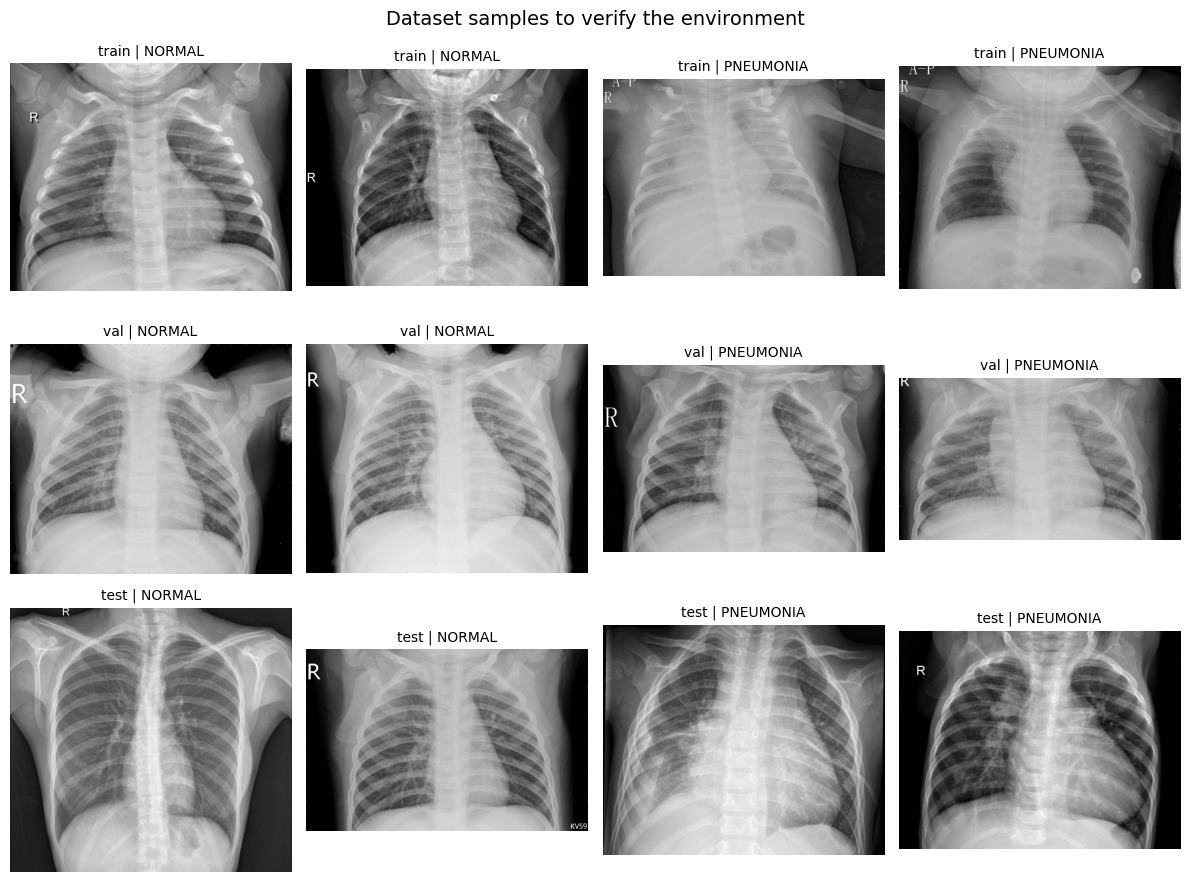

Dataset visualized from: /home/emilio/Desktop/TESIS/data/raw/chest_xray


In [7]:
raw_dataset_path = Path.cwd() / "data" / "raw"
dataset_root = raw_dataset_path / "chest_xray"

subsets = ["train", "val", "test"]
classes = ["NORMAL", "PNEUMONIA"]
per_class = 2
samples_rows = []

for subset in subsets:
    subset_samples = []
    for cls in classes:
        cls_dir = dataset_root / subset / cls
        candidates = sorted(cls_dir.glob("*.jp*g")) or sorted(cls_dir.glob("*.png"))
        picks = random.sample(candidates, min(per_class, len(candidates)))
        for p in picks:
            subset_samples.append((cls, p))
    samples_rows.append((subset, subset_samples))

cols = max(len(samples) for _, samples in samples_rows)
fig, axes = plt.subplots(
    len(samples_rows),
    cols,
    figsize=(cols * 3, len(samples_rows) * 3)
)
if len(samples_rows) == 1:
    axes = [axes]
if cols == 1:
    axes = [[ax] for ax in axes]

for row_idx, (subset, samples) in enumerate(samples_rows):
    for col_idx in range(cols):
        ax = axes[row_idx][col_idx]
        ax.axis("off")
        if col_idx >= len(samples):
            continue
        cls, path = samples[col_idx]
        with Image.open(path) as img:
            ax.imshow(img, cmap="gray")
        ax.set_title(f"{subset} | {cls}", fontsize=10)

plt.suptitle("Dataset samples to verify the environment", fontsize=14)
plt.tight_layout()
plt.show()
print(f"Dataset visualized from: {dataset_root}")